<a href="https://colab.research.google.com/github/proshenjitbarua06-dot/skill-morph/blob/main/revised_smart_grid_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
Dataset Shape: (4000, 22)

Fault Severity Distribution:
Fault Severity
High      1777
Low       1771
Medium     452
Name: count, dtype: int64
Selected Features: ['Current Magnitude (A)', 'Active Power (kW)', 'Reactive Power (kVAR)', 'Load Demand (kW)', 'Frequency Variation (Hz)', 'Power Factor', 'Temperature Value (°C)', 'Wind Speed (m/s)', 'Solar Irradiance (W/m²)', 'Grid Stability Index', 'Line Loss (kW)', 'Renewable Contribution (%)']

=== FINAL MODEL PERFORMANCE ===
                 Model  Accuracy  Precision  Recall  F1-Weighted     MCC  \
0        Random Forest    1.0000     1.0000  1.0000       1.0000  1.0000   
2    Gradient Boosting    1.0000     1.0000  1.0000       1.0000  1.0000   
3    Voting Classifier    1.0000     1.0000  1.0000       1.0000  1.0000   
4  Stacking Classifier    1.0000     1.0000  1.0000       1.0000  1.0000   
1          Extra Trees    0.9562     0.9574  0.9562       0.9563  0.9271   
5                  SVM    0.8775     0.8774

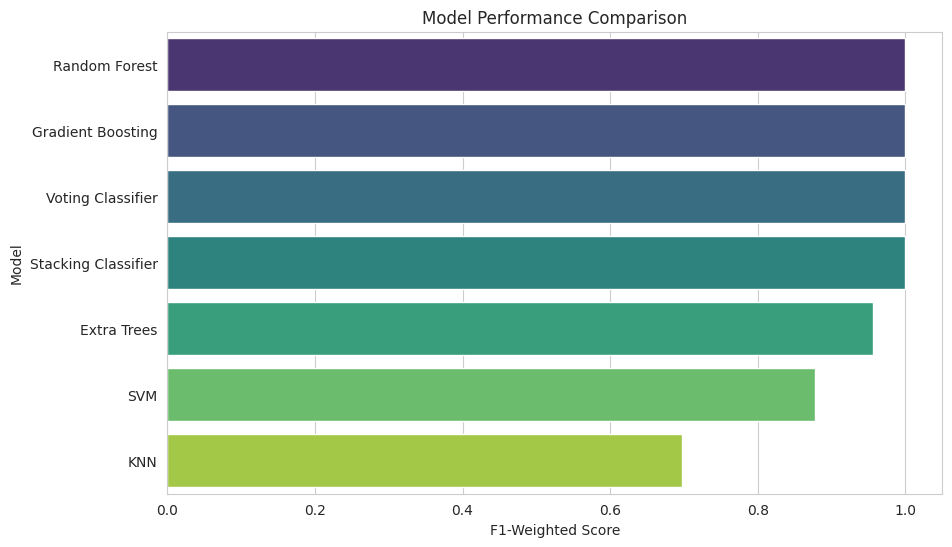

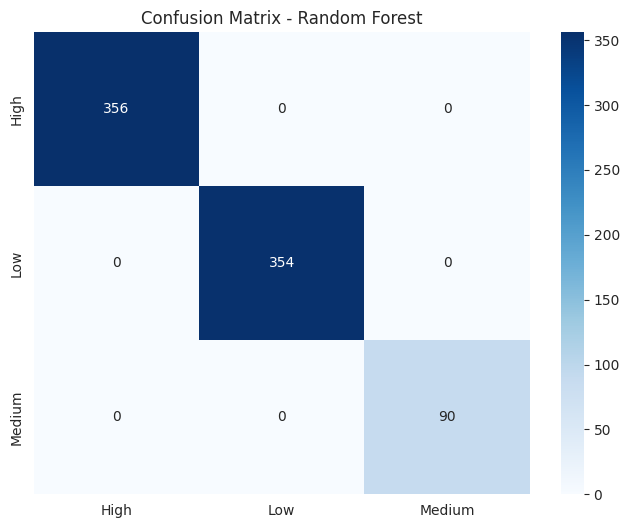

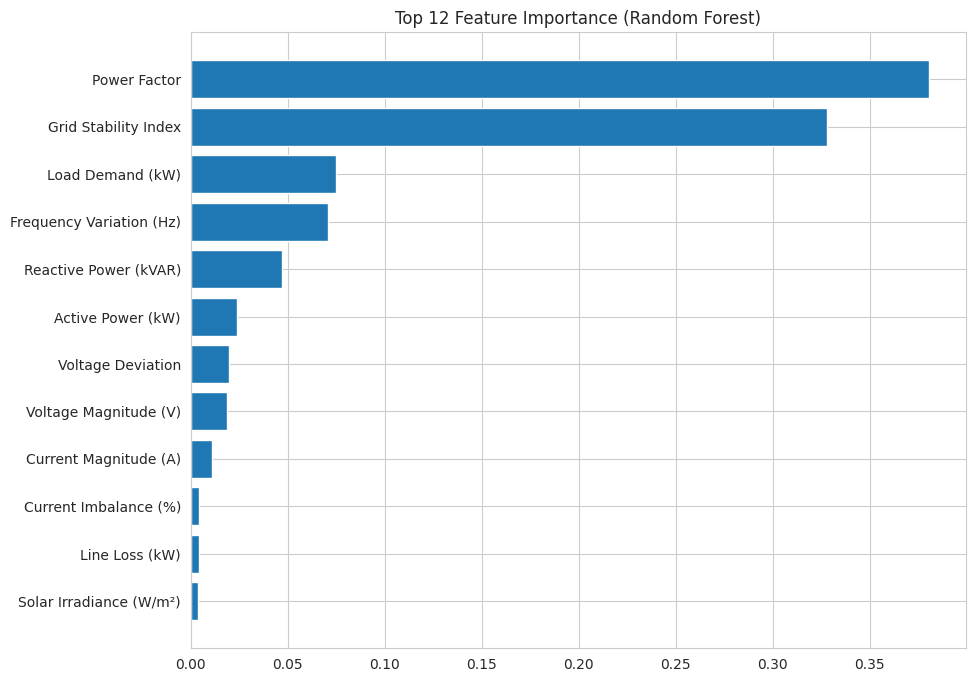


=== Noise Robustness Analysis ===
Noise σ=0.000 → F1 = 1.0000
Noise σ=0.030 → F1 = 0.9787
Noise σ=0.060 → F1 = 0.9687
Noise σ=0.090 → F1 = 0.9612
Noise σ=0.120 → F1 = 0.9375
Noise σ=0.150 → F1 = 0.9210


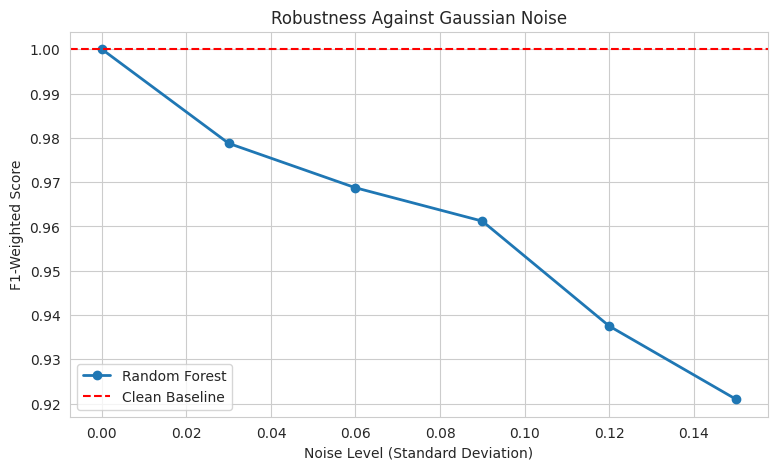


IEEE-STYLE RESULTS TABLE
              Model  Accuracy  Precision  Recall  F1-Weighted    MCC  CV_F1_Mean  CV_F1_Std  Train_Time(s)
      Random Forest    1.0000     1.0000  1.0000       1.0000 1.0000      0.9989     0.0012          24.84
  Gradient Boosting    1.0000     1.0000  1.0000       1.0000 1.0000      0.9989     0.0015          86.23
  Voting Classifier    1.0000     1.0000  1.0000       1.0000 1.0000      0.9992     0.0009         106.68
Stacking Classifier    1.0000     1.0000  1.0000       1.0000 1.0000      0.9992     0.0009         529.28
        Extra Trees    0.9562     0.9574  0.9562       0.9563 0.9271      0.9527     0.0085           7.81
                SVM    0.8775     0.8774  0.8775       0.8774 0.7933      0.9033     0.0111          18.63
                KNN    0.7075     0.7058  0.7075       0.6977 0.4954      0.7754     0.0168           0.17

Best Performing Model: Random Forest


In [1]:
# =============================================================================
# Q1: A Robust Machine Learning Framework for Smart Grid Power Monitoring
# Integrating Stratified K-Fold Validation and Ensemble Classifiers
# =============================================================================

from google.colab import drive
drive.mount('/content/drive')

!pip install -q shap imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             confusion_matrix, roc_auc_score, matthews_corrcoef,
                             classification_report)

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectKBest, f_classif

from scipy.stats import ttest_rel, wilcoxon

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)

# ========================== 1. LOAD & EXPLORE DATA ==========================
df = pd.read_csv("/content/drive/MyDrive/Dataset/Smart Grid Power Monitoring Dataset.csv")

print("Dataset Shape:", df.shape)
print("\nFault Severity Distribution:")
print(df['Fault Severity'].value_counts())

le = LabelEncoder()
y = le.fit_transform(df['Fault Severity'])
classes = le.classes_

features = ['Voltage Magnitude (V)', 'Current Magnitude (A)', 'Active Power (kW)',
            'Reactive Power (kVAR)', 'Load Demand (kW)', 'Frequency Variation (Hz)',
            'Power Factor', 'Temperature Value (°C)', 'Humidity Level (%)',
            'Wind Speed (m/s)', 'Solar Irradiance (W/m²)', 'Grid Stability Index',
            'Voltage Deviation', 'Line Loss (kW)', 'Current Imbalance (%)',
            'Renewable Contribution (%)']

X = df[features].copy()

# ========================== 2. PREPROCESSING ==========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42)

# SMOTE + Feature Selection on full scaled data
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)

selector = SelectKBest(score_func=f_classif, k=12)
X_selected = selector.fit_transform(X_res, y_res)
selected_features = np.array(features)[selector.get_support()].tolist()

print("Selected Features:", selected_features)

# ========================== 3. MODELS ==========================
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
et = ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1)
gb = GradientBoostingClassifier(random_state=42)
voting = VotingClassifier([('rf', rf), ('et', et), ('gb', gb)], voting='soft')
stacking = StackingClassifier(
    estimators=[('rf', rf), ('et', et), ('gb', gb)],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)

models = {
    "Random Forest": rf,
    "Extra Trees": et,
    "Gradient Boosting": gb,
    "Voting Classifier": voting,
    "Stacking Classifier": stacking,
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

# ========================== 4. EVALUATION ==========================
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results = []

for name, model in models.items():
    start_time = time.time()

    cv_scores = cross_val_score(model, X_res, y_res, cv=skf, scoring='f1_weighted', n_jobs=-1)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    train_time = time.time() - start_time

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1-Weighted": f1_score(y_test, y_pred, average='weighted'),
        "MCC": matthews_corrcoef(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted'),
        "CV_F1_Mean": cv_scores.mean(),
        "CV_F1_Std": cv_scores.std(),
        "Train_Time(s)": round(train_time, 2)
    })

results_df = pd.DataFrame(results).sort_values("F1-Weighted", ascending=False)
print("\n=== FINAL MODEL PERFORMANCE ===")
print(results_df.round(4))

# ========================== 5. STATISTICAL TEST ==========================
scores_stack = cross_val_score(stacking, X_res, y_res, cv=skf, scoring='f1_weighted', n_jobs=-1)
scores_rf = cross_val_score(rf, X_res, y_res, cv=skf, scoring='f1_weighted', n_jobs=-1)

t_p = ttest_rel(scores_stack, scores_rf)[1]
w_p = wilcoxon(scores_stack, scores_rf)[1]
cohen_d = (scores_stack.mean() - scores_rf.mean()) / scores_rf.std()

print(f"\nStacking vs RF → t-test p-value: {t_p:.4f} | Wilcoxon p: {w_p:.4f} | Cohen's d: {cohen_d:.3f}")

# ========================== 6. VISUALIZATIONS ==========================

# Performance Comparison
plt.figure(figsize=(10,6))
sns.barplot(data=results_df, x="F1-Weighted", y="Model", palette="viridis")
plt.title("Model Performance Comparison")
plt.xlabel("F1-Weighted Score")
plt.show()

# Confusion Matrix (Best Model)
best_model = models[results_df.iloc[0]["Model"]]
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title(f"Confusion Matrix - {results_df.iloc[0]['Model']}")
plt.show()

# Feature Importance
rf.fit(X_res, y_res)
importances = rf.feature_importances_
idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10,8))
plt.barh(range(12), importances[idx[:12]])
plt.yticks(range(12), [features[i] for i in idx[:12]])
plt.title("Top 12 Feature Importance (Random Forest)")
plt.gca().invert_yaxis()
plt.show()

# Noise Robustness
print("\n=== Noise Robustness Analysis ===")
noise_levels = np.linspace(0, 0.15, 6)
f1_scores = []
rf.fit(X_train, y_train)
baseline = f1_score(y_test, rf.predict(X_test), average='weighted')

for noise in noise_levels:
    X_noisy = X_test + np.random.normal(0, noise, X_test.shape)
    f1 = f1_score(y_test, rf.predict(X_noisy), average='weighted')
    f1_scores.append(f1)
    print(f"Noise σ={noise:.3f} → F1 = {f1:.4f}")

plt.figure(figsize=(9,5))
plt.plot(noise_levels, f1_scores, 'o-', linewidth=2, label='Random Forest')
plt.axhline(baseline, color='r', linestyle='--', label='Clean Baseline')
plt.xlabel("Noise Level (Standard Deviation)")
plt.ylabel("F1-Weighted Score")
plt.title("Robustness Against Gaussian Noise")
plt.legend()
plt.grid(True)
plt.show()

# ========================== 7. FINAL TABLE ==========================
final_table = results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Weighted',
                          'MCC', 'CV_F1_Mean', 'CV_F1_Std', 'Train_Time(s)']].round(4)

print("\n" + "="*90)
print("IEEE-STYLE RESULTS TABLE")
print("="*90)
print(final_table.to_string(index=False))
print(f"\nBest Performing Model: {results_df.iloc[0]['Model']}")

# Save
results_df.to_csv("/content/drive/MyDrive/smart_grid_final_results.csv", index=False)